In [16]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random
import time

import keras

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only those gestures
CONDITIONS = ['like', 'stop']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

PATH = '../gesture_dataset_sample'

## helper function to load and parse annotations

In [17]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'{PATH}/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

In [18]:
# pretty-print first element
#000484ab-5fd0-49b8-9253-23a22b71d7b1
print(json.dumps(annotations['like']['0014182f-d756-42b3-896c-c52de76926bb'], indent=2))

{
  "bboxes": [
    [
      0.38056273,
      0.35650891,
      0.17322347,
      0.10461114
    ]
  ],
  "labels": [
    "like"
  ],
  "landmarks": [
    [
      [
        0.5497169170918876,
        0.4276043615779976
      ],
      [
        0.5218336293004483,
        0.40536586667786917
      ],
      [
        0.48288133220125257,
        0.3930262243722419
      ],
      [
        0.4501841862302019,
        0.37981099195030416
      ],
      [
        0.44251365410099686,
        0.36620499322043343
      ],
      [
        0.43138297470865106,
        0.406093902776592
      ],
      [
        0.4072660997339628,
        0.4073950234480344
      ],
      [
        0.42588200316326846,
        0.40612291879594015
      ],
      [
        0.4441470003072778,
        0.4049221293588555
      ],
      [
        0.4314493576491367,
        0.4212979654419442
      ],
      [
        0.42096276272263283,
        0.4180224457320293
      ],
      [
        0.43966095717106257,
      

## helper function to pre-process images (color channel conversion and resizing)

In [19]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load images and annotations

In [20]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f'{PATH}/{condition}')):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'{PATH}/{condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

## let's have a look at one of the images

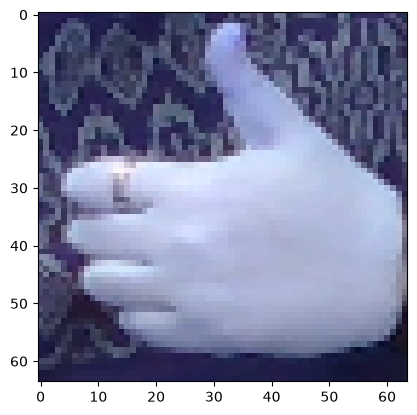

In [21]:
plt.imshow(random.sample(images, 1)[0])
#plt.imshow(random.sample(images, 1)[0], cmap='gray')

## split data set into train and test

x is for the actual data, y is for the label (this is convention)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

512
128
512
128


## transform data sets into a format compatible with our neural network

image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]

furthermore, scale all values to a range of 0 to 1

training data has to be converted to a categorial vector ("one hot"):

[3] --> [0, 0, 0, 1, 0, ..., 0]

In [23]:
# Convert to float
X_train = np.array(X_train).astype('float32')
# Normalization [0,1]
X_train = X_train / 255.

X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.


# Convert interger class labels in to one hot vector
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

# rename for demonstration purposes
train_label = y_train_one_hot
test_label = y_test_one_hot

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

(512, 64, 64, 3) (128, 64, 64, 3) (512, 3) (128, 3)


## define array containing different activation functions for the fully connected layers

In [24]:
activation_functions = ['relu', 'tanh', 'sigmoid', 'leaky_relu']

## approach:

My randomly selected hyperparameter to evaluate is "Activation function of the fully connected layers". To evaluate this i kept the approach simple. I used the CNN from the notebook as a starting point and modified it in a way, that it instatniates and trains four different modesl. One for each activation function. As the different values i selected the most common / well know activation functions which are:

- ReLU
- tanh
- sigmoid
- Leaky ReLU

I think this selection i quite good, as im comparing two modern, standard activation functions (ReLU, leaky ReLU) against two older, traditional ones (sigmoid, tanh). Because ReLU and leaky ReLU are nowadays considered the standard, i expect them to perform bettern than tanh and sigmoid. From the module "Grundlagen des maschinellen Lernene" i know that ReLU and leaky ReLU do not squash the values and therefore allow positive gradients to flow "freely", for this reason i expect them to converge the fastest that both produce very similar curves. Leaky ReLU is designed to solve the dying ReLU problem, but for this to occur rather certain conditions are needed. So i expect very similar performance.

Sigmoid and tanh both squash the output either between 0 and 1 (sigmoid) or -1 and 1 and therefore are well known to suffer from the vanishing gradient problem. For this reason i assume that those perform less good than the two modern alternatives. From previously taken AI modules i know (or atleast i think to know) that tanh usually performs better than sigmoid, but i dont know the reason anymore. I think it hase something to do with being centered around 0 and not 0.5. 

So summarized i expect ReLU and leaky ReLU to perform the best, followed by tanh and then sigmoid.

Regarding the inference time im not to sure what to assume. ReLU and leaky ReLU are mor trivial operations than tanh and sigmoid. So technically they should be faster when it comes to inference time. But all of those functions are rather trivial for a modern computer so i expect to not see much of a difference in any of those actually.



## instantiate models with different activation functions and train

In [25]:
# store models, training histories and inference times for each activation function in a dict
models = {}
histories = {}
inference_times = {}

# loop over all activation functions and train a model for each of them
for activation in activation_functions:
    # variables for hyperparameters
    batch_size = 8 
    epochs = 50 
    num_classes = len(label_names)
    activation = activation
    activation_conv = 'leaky_relu'
    layer_count = 2
    num_neurons = 64

    # define model structure
    # with keras, we can use a model's add() function to add layers to the network one by one
    model = Sequential()

    # data augmentation (this can also be done beforehand - but don't augment the test dataset!)
    model.add(RandomFlip('horizontal'))
    model.add(RandomContrast(0.1))
    #model.add(RandomBrightness(0.1))
    #model.add(RandomRotation(0.2))

    # first, we add some convolution layers followed by max pooling
    model.add(Conv2D(64, kernel_size=(9, 9), activation=activation_conv, input_shape=(SIZE[0], SIZE[1], COLOR_CHANNELS), padding='same'))
    model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

    model.add(Conv2D(32, (5, 5), activation=activation_conv, padding='same'))
    model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

    model.add(Conv2D(32, (3, 3), activation=activation_conv, padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

    # Randomly disables 20% of neurons during each training step
    model.add(Dropout(0.2))

    # after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
    model.add(Flatten())

    # add some fully connected layers ("Dense")
    for i in range(layer_count - 1):
        model.add(Dense(num_neurons, activation=activation))

    model.add(Dense(num_neurons, activation=activation))

    # for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
    model.add(Dense(num_classes, activation='softmax'))

    # specify loss function, optimizer and evaluation metrics
    # for classification, categorial crossentropy is used as a loss function
    # use the adam optimizer unless you have a good reason not to
    model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

    # define callback functions that react to the model's behavior during training
    # in this example, we reduce the learning rate once we get stuck and early stopping
    # to cancel the training if there are no improvements for a certain amount of epochs

    # If validation loss stops improving for 2 epochs, multiply  the learning rate by 0.2 (slow down/fine tune)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
    # if validation loss doesn't improve for 3 epchs, stop training entierly
    stop_early = EarlyStopping(monitor='val_loss', patience=3)
    
    history = model.fit(
        X_train,
        train_label,
        batch_size=batch_size,
        epochs=epochs,
        verbose=1,
        validation_data=(X_test, test_label),
        callbacks=[reduce_lr, stop_early]
    )
    
    start_time = time.time()
    predictions = model.predict(X_test)
    end_time = time.time()
    total_inference_time = end_time - start_time
    per_image_inference_time = total_inference_time / len(X_test)
    
    inference_times[activation] = per_image_inference_time
    models[activation] = model
    histories[activation] = history

Epoch 1/50
64/64 [==============================] - 1s 7ms/step - loss: 1.0744 - accuracy: 0.4004 - val_loss: 1.0318 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 2/50
64/64 [==============================] - 0s 5ms/step - loss: 1.0445 - accuracy: 0.4277 - val_loss: 1.0216 - val_accuracy: 0.5312 - lr: 0.0010
Epoch 3/50
64/64 [==============================] - 0s 5ms/step - loss: 0.8666 - accuracy: 0.5977 - val_loss: 0.8237 - val_accuracy: 0.6484 - lr: 0.0010
Epoch 4/50
64/64 [==============================] - 0s 5ms/step - loss: 0.5297 - accuracy: 0.7812 - val_loss: 0.3490 - val_accuracy: 0.8594 - lr: 0.0010
Epoch 5/50
64/64 [==============================] - 0s 5ms/step - loss: 0.3862 - accuracy: 0.8691 - val_loss: 0.5029 - val_accuracy: 0.8516 - lr: 0.0010
Epoch 6/50
64/64 [==============================] - 0s 5ms/step - loss: 0.2609 - accuracy: 0.9238 - val_loss: 0.2370 - val_accuracy: 0.9297 - lr: 0.0010
Epoch 7/50
64/64 [==============================] - 0s 5ms/step - loss: 0.2050 - a

## print final prediction accuracy and loss

In [26]:
for activation, model in models.items():
    test_loss, test_acc = model.evaluate(X_test, test_label, verbose=0)
    print(f'Activation: {activation}, Test accuracy: {test_acc:.4f}')


Activation: relu, Test accuracy: 0.9375
Activation: tanh, Test accuracy: 0.9453
Activation: sigmoid, Test accuracy: 0.9062
Activation: leaky_relu, Test accuracy: 0.9531


## plot accuracy and loss of the training process

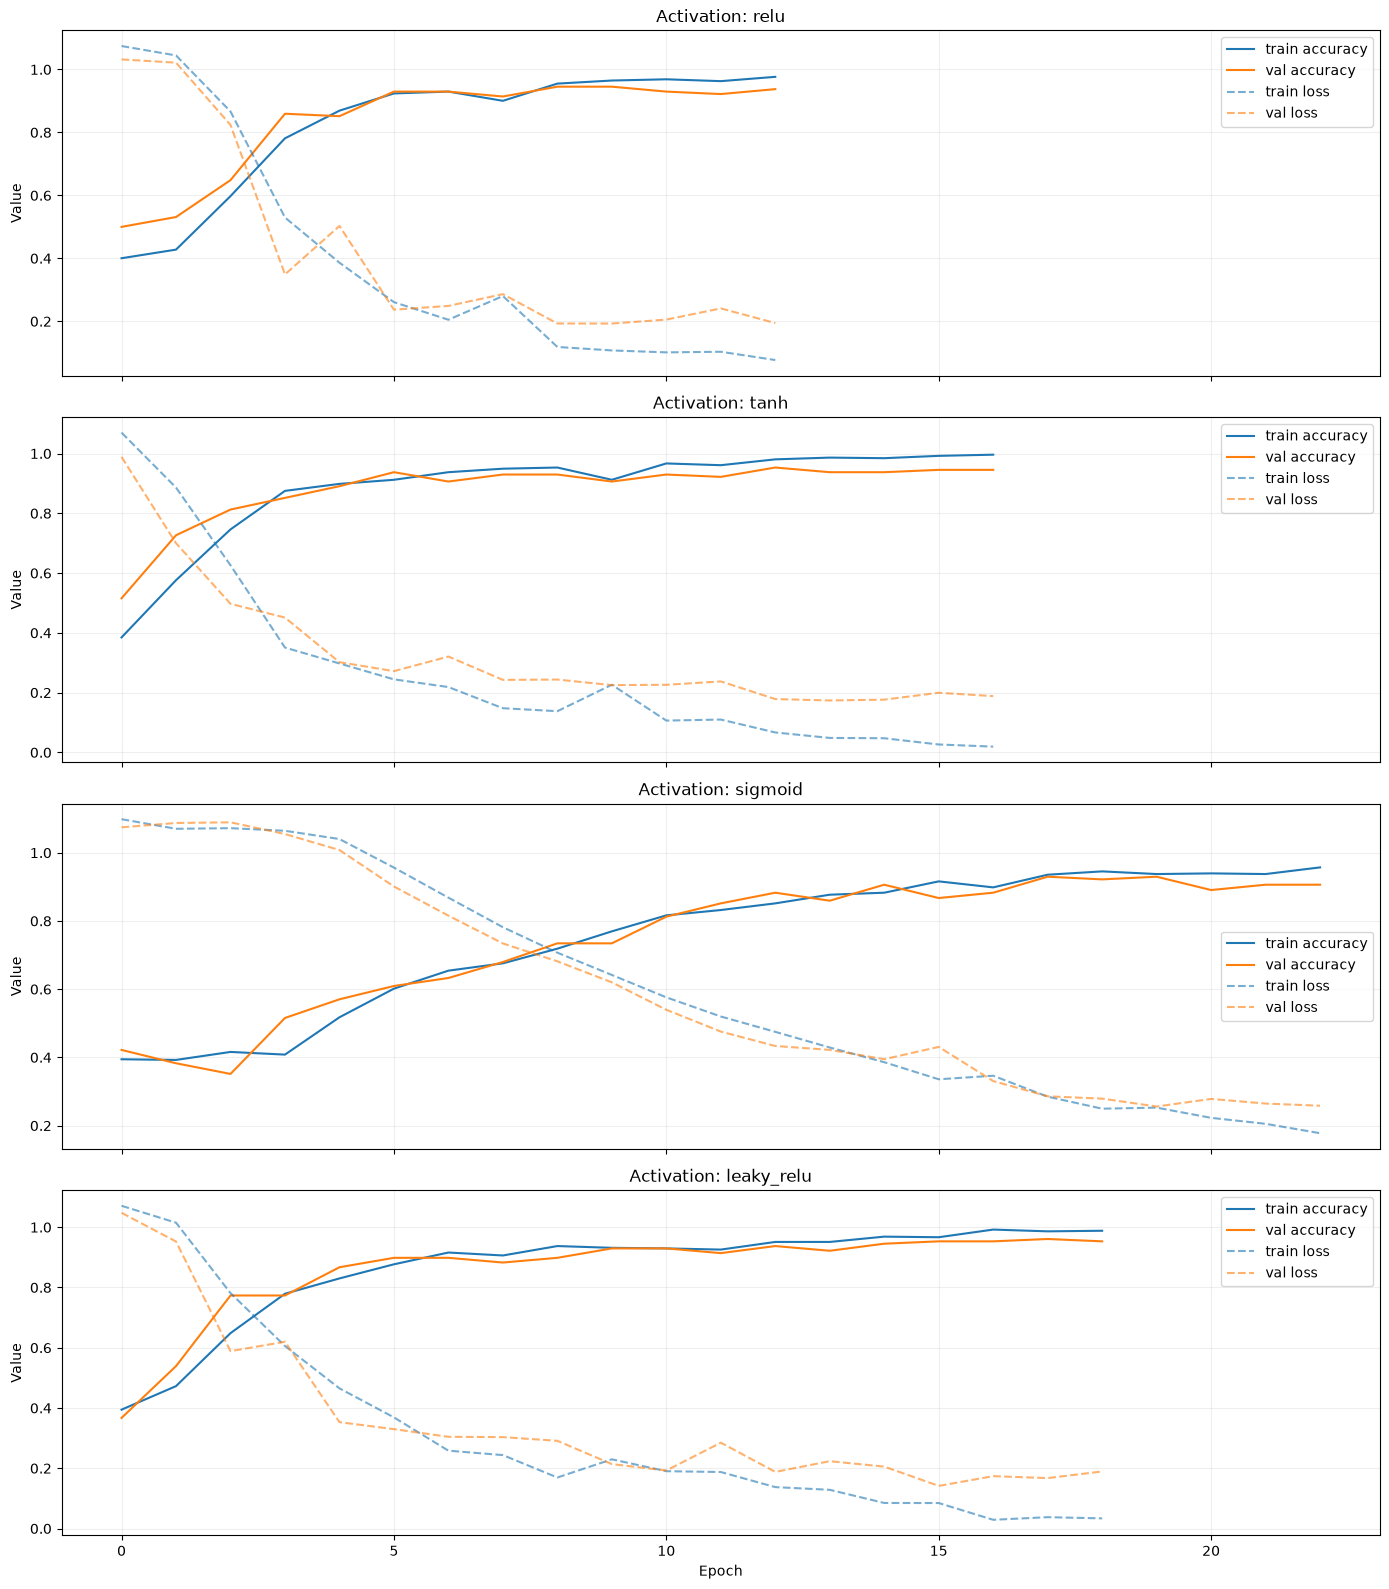

In [ ]:
fig, axes = plt.subplots(len(activation_functions), 1, figsize=(14, 4 * len(activation_functions)), sharex=True)

# plot training and validation accuracy and loss for each activation function
for ax, activation in zip(axes, activation_functions):
    history = histories[activation].history

    ax.plot(history['accuracy'], label='train accuracy', color='tab:blue')
    ax.plot(history['val_accuracy'], label='val accuracy', color='tab:orange')
    ax.plot(history['loss'], linestyle='--', label='train loss', color='tab:blue', alpha=0.6)
    ax.plot(history['val_loss'], linestyle='--', label='val loss', color='tab:orange', alpha=0.6)

    ax.set_title(f'Activation: {activation}')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.2)
    ax.legend(loc='best')

axes[-1].set_xlabel('Epoch')
plt.tight_layout()
plt.show()

## plot inference times

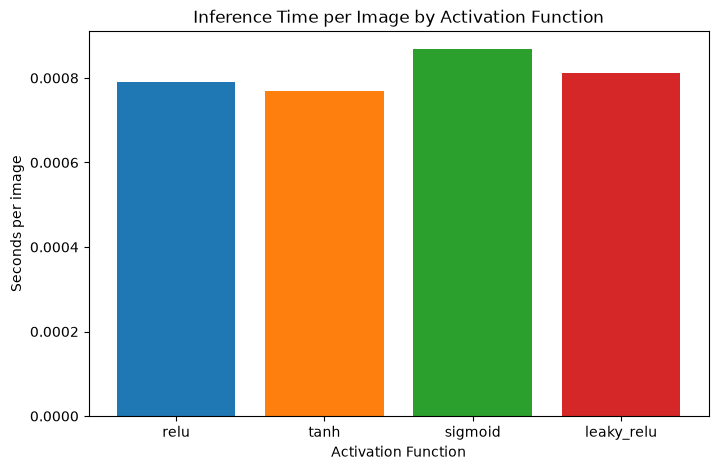

In [28]:
# Plot inference times
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(inference_times.keys(), inference_times.values(), color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
ax.set_title('Inference Time per Image by Activation Function')
ax.set_ylabel('Seconds per image')
ax.set_xlabel('Activation Function')
plt.show()

## findings

**The results have slightly changed since i moved to python 3.11 for the mediapipe compatibility, so there are two versions of my findings**

**Old findings:**

Looking at the results it seems like my assumptions were close to spot on. All activation functions lead to a model with an accuracy of over 90%. Looking at the accuracies from the training histories, it becomes clear that my assumptions were quite good. ReLU and leaky ReLU perform nearly identical. Tanh looks quite strong aswell converging very fast in the beginning, but then taking some time until the early stopping criteria is met, resulting in a bit longer training time. As expected sigmoid performs the worst, it takes more then 3 times the amount of epochs until the early stopping criteria is met. So when it comes to the needed amount of training iterations ReLU and leaky ReLu are the clear winners.

The final prediction accuracies of all activation functions are nearly the same, with all of them yielding over 90%. Yet tanh and leaky ReLU share the first place with both of them reaching a prediction accuracy of 0.9453.

The results of the inference time are pretty much what i expected, when it comes to how close all inference times are together. All of them take somewhere between 0.5 and 0.7 ms. Yet it comes as a suprise that the ReLU function takes the longest while all other are nearly identical. Im not sure what the reason for this is but it might have something todo with the actual implementation in python. Technocally ReLU and leaky ReLU are mathematically the simplest functions. But in the end this doesnt really matter since the inference time i so small and the differences are not very significant.

**New findings:**

By using the python 3.11 interpreter the results have changed quite a bit. Previously my approach and expectations were matched pretty much perfectly. Now the leaky ReLU function delivers the highes prediction accuracy, but looking at the training progress ReLU converges the fastest followed by tanh, then leaky ReLU and finally the sigmoid function. I dont know what the exact reason for this is but i think because i moved to python 3.11 the implementation in code changed quite a bit. Also all models with the different activations functions converge slower than before with the 3.12 interpreter.

Looking at the inference times, all models have a very close performance but now sigmoid is the slowest. Which makes a little more sense than before. But it can be observed that all models now infer predictions slower indicating some optimizations either with newer versions of tensorflow/keras or python 3.12. Still all models infer very fast and nearly the same.